<a href="https://colab.research.google.com/github/beyzahiz/Sentiment-Analysis-NLP/blob/main/01_sentiment_analysis_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
## Dataset Overview

#This dataset contains 50,000 movie reviews labeled as positive or negative.

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
import os
os.listdir()

['.config', 'IMDB Dataset.csv', 'sample_data']

In [82]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [83]:
print(df.shape)
print(df.columns)

(50000, 2)
Index(['review', 'sentiment'], dtype='object')


In [84]:
df.isnull().sum()

,0
review,0
sentiment,0


In [85]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


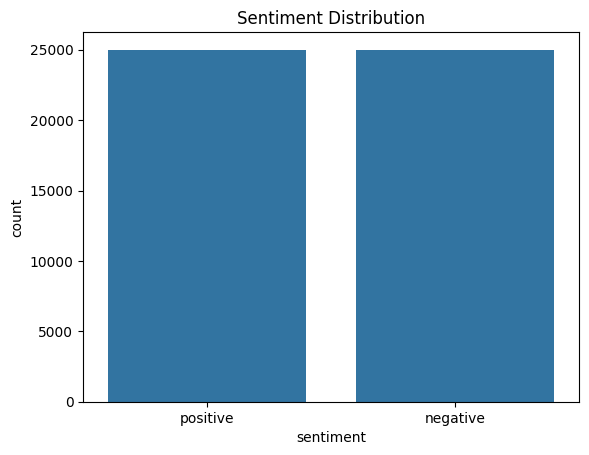

In [86]:
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

In [87]:
df['review_length'] = df['review'].apply(len) #her review'un karakter sayısı hesaplanıyor
df['review_length'].describe()

,review_length
count,50000.000000
mean,1309.431020
std,989.728014
min,32.000000
25%,699.000000
50%,970.000000
75%,1590.250000
max,13704.000000


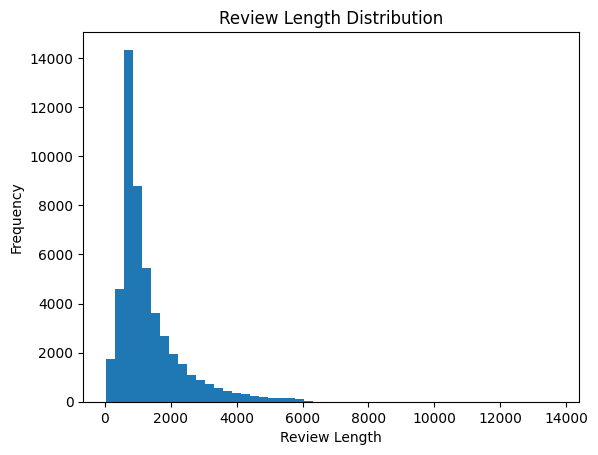

In [88]:
plt.hist(df['review_length'], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Review Length")
plt.ylabel("Frequency")
plt.show()

In [89]:
text = " ".join(df['review'])  #bütün yorumları tek metin yapar

In [90]:
from collections import Counter
words = text.split()
word_freq = Counter(words)  #counter her kelimenin kaç kez geçtiğini sayar
word_freq.most_common(20)  #en sık geçen kelimeler

[('the', 568735),
 ('a', 306960),
 ('and', 301919),
 ('of', 283625),
 ('to', 261850),
 ('is', 203056),
 ('in', 169981),
 ('I', 132498),
 ('that', 126818),
 ('this', 113726),
 ('it', 107916),
 ('/><br', 100974),
 ('was', 92658),
 ('as', 83130),
 ('with', 82569),
 ('for', 80919),
 ('The', 67317),
 ('but', 66282),
 ('on', 61197),
 ('movie', 60762)]

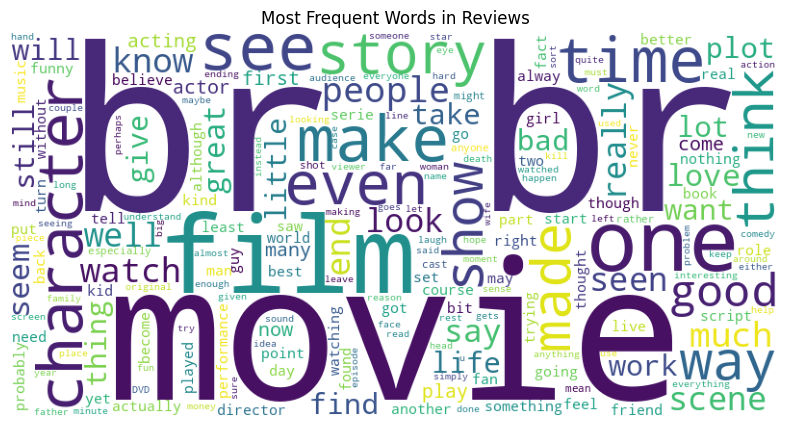

In [91]:
!pip install wordcloud
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Frequent Words in Reviews")
plt.show()

In [97]:
positive_reviews = df[df['sentiment'] == 'positive']['review']
negative_reviews = df[df['sentiment'] == 'negative']['review']

positive_text = " ".join(positive_reviews.astype(str))
negative_text = " ".join(negative_reviews.astype(str))

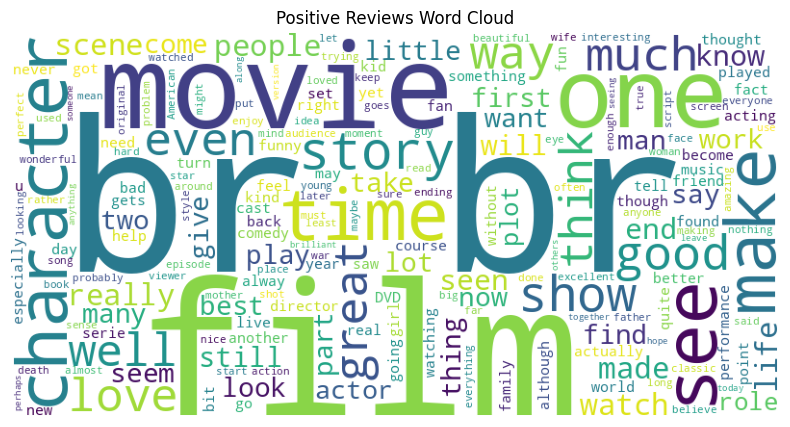

In [98]:
positive_wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(positive_wc)
plt.axis("off")
plt.title("Positive Reviews Word Cloud")
plt.show()

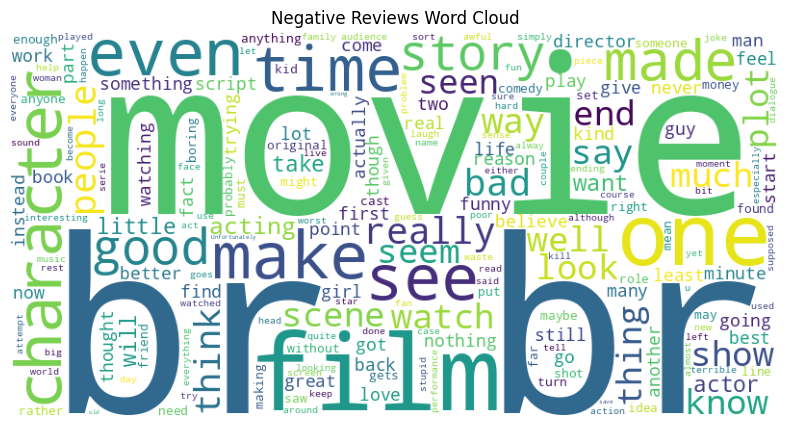

In [99]:
negative_wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(negative_wc)
plt.axis("off")
plt.title("Negative Reviews Word Cloud")
plt.show()